In [1]:
import warnings
warnings.filterwarnings('ignore')

Import required  libraries

In [2]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns

Read the data

In [3]:
df=pd.read_csv('electricity_consumption_based_weather_dataset.csv')

Display Dataset


In [4]:
df.head()

,date,AWND,PRCP,TMAX,TMIN,daily_consumption
0,2006-12-16,2.5,0.0,10.6,5.0,1209.176
1,2006-12-17,2.6,0.0,13.3,5.6,3390.460
2,2006-12-18,2.4,0.0,15.0,6.7,2203.826
3,2006-12-19,2.4,0.0,7.2,2.2,1666.194
4,2006-12-20,2.4,0.0,7.2,1.1,2225.748


In [5]:
df.tail()

,date,AWND,PRCP,TMAX,TMIN,daily_consumption
1428,2010-11-22,2.7,0.0,18.3,7.2,2041.536
1429,2010-11-23,3.1,0.0,16.1,10.0,1577.536
1430,2010-11-24,4.3,0.0,10.0,5.0,1796.248
1431,2010-11-25,1.6,1.5,7.8,3.9,1431.164
1432,2010-11-26,3.1,4.1,11.7,3.3,1488.104


Shape of the dataset

In [6]:
df.shape

(1433, 6)

Column in dataset

In [7]:
df.columns

Index(['date', 'AWND', 'PRCP', 'TMAX', 'TMIN', 'daily_consumption'], dtype='str')

dataset info

In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1433 entries, 0 to 1432
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   date               1433 non-null   str    
 1   AWND               1418 non-null   float64
 2   PRCP               1433 non-null   float64
 3   TMAX               1433 non-null   float64
 4   TMIN               1433 non-null   float64
 5   daily_consumption  1433 non-null   float64
dtypes: float64(5), str(1)
memory usage: 67.3 KB


statistical description

In [9]:
df.describe()

,AWND,PRCP,TMAX,TMIN,daily_consumption
count,1418.000000,1433.000000,1433.000000,1433.000000,1433.000000
mean,2.642313,3.800488,17.187509,9.141242,1561.078061
std,1.140021,10.973436,10.136415,9.028417,606.819667
min,0.000000,0.000000,-8.900000,-14.400000,14.218000
25%,1.800000,0.000000,8.900000,2.200000,1165.700000
50%,2.400000,0.000000,17.800000,9.400000,1542.650000
75%,3.300000,1.300000,26.100000,17.200000,1893.608000
max,10.200000,192.300000,39.400000,27.200000,4773.386000


Check datatypes


df.dtypes

In [10]:
df.isnull().sum()

date                  0
AWND                 15
PRCP                  0
TMAX                  0
TMIN                  0
daily_consumption     0
dtype: int64

In [11]:
(df.isnull().sum()/len(df))*100

date                 0.000000
AWND                 1.046755
PRCP                 0.000000
TMAX                 0.000000
TMIN                 0.000000
daily_consumption    0.000000
dtype: float64

In [12]:
df.duplicated().sum()

np.int64(0)

In [13]:
df[df.duplicated()]

,date,AWND,PRCP,TMAX,TMIN,daily_consumption


remove duplicate values

In [14]:
df = df.drop_duplicates()

In [15]:
df.duplicated().sum()

np.int64(0)

In [52]:
df['date'] = pd.to_datetime(df['date'])

In [53]:
df = df.sort_values('date')

In [54]:
df.head(30)

,date,AWND,PRCP,TMAX,TMIN,daily_consumption,year,month,day,day_of_week,lag_1,lag_7,rolling_7,rolling_30
58,2007-02-12,2.6,0.0,4.4,-2.2,1877.610,2007,2,12,0,3571.228,1645.280,NaN,NaN
59,2007-02-13,3.6,0.8,0.0,-5.6,1414.546,2007,2,13,1,1877.610,1273.480,NaN,NaN
60,2007-02-14,6.2,23.9,-1.7,-8.9,2498.672,2007,2,14,2,1414.546,2328.018,NaN,NaN
61,2007-02-15,4.7,0.0,-4.4,-9.4,1985.346,2007,2,15,3,2498.672,1801.414,NaN,NaN
62,2007-02-16,4.4,0.0,-1.7,-10.0,1702.528,2007,2,16,4,1985.346,1620.198,NaN,NaN
63,2007-02-17,2.9,0.0,1.7,-7.2,2076.912,2007,2,17,5,1702.528,2829.328,NaN,NaN
64,2007-02-18,3.4,0.0,1.1,-7.8,3829.762,2007,2,18,6,2076.912,3571.228,2197.910857,NaN
65,2007-02-19,4.3,0.0,-1.1,-11.1,2186.614,2007,2,19,0,3829.762,1877.610,2242.054286,NaN
66,2007-02-20,2.7,2.5,8.3,-1.7,3149.928,2007,2,20,1,2186.614,1414.546,2489.966000,NaN
67,2007-02-21,1.3,0.3,9.4,3.9,2072.874,2007,2,21,2,3149.928,2498.672,2429.137714,NaN


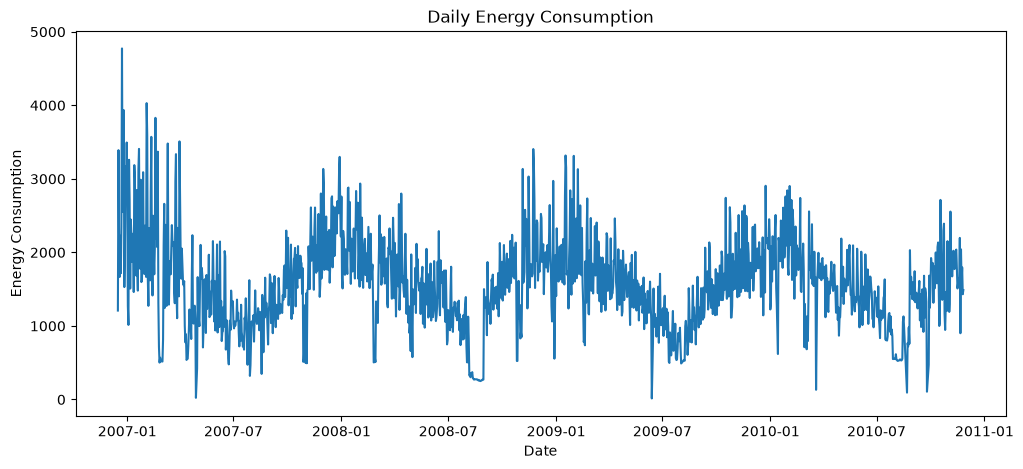

In [19]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
plt.plot(df['date'], df['daily_consumption'])
plt.xlabel("Date")
plt.ylabel("Energy Consumption")
plt.title("Daily Energy Consumption")
plt.show()

In [69]:
df['year'] = df['date'].dt.year
df['day'] = df['date'].dt.day

In [ ]:
df['month'] = df['date'].dt.month

In [64]:
monthly_demand = df.groupby('month')['daily_consumption'].mean()

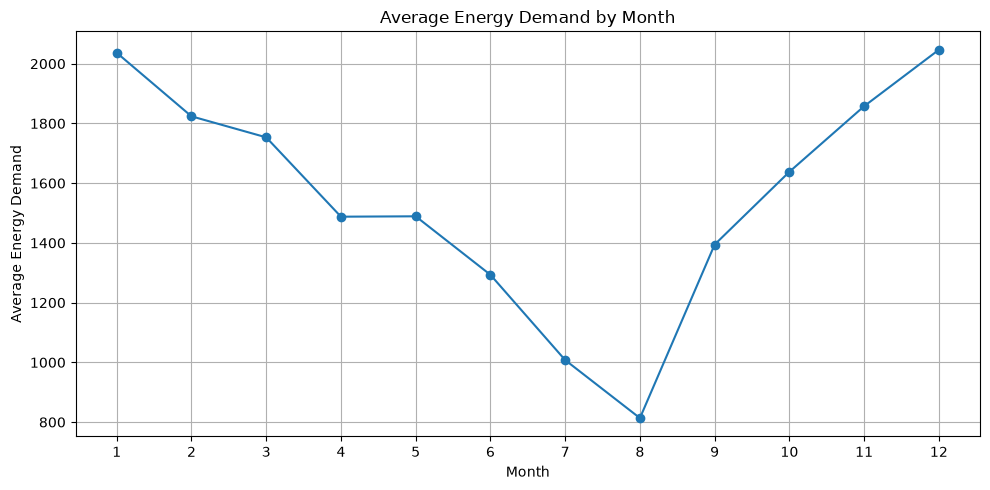

In [65]:
plt.figure(figsize=(10, 5))

plt.plot(monthly_demand.index, monthly_demand.values, marker='o')

plt.xlabel("Month")
plt.ylabel("Average Energy Demand")
plt.title("Average Energy Demand by Month")
plt.xticks(range(1, 13))
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
df['day_of_week'] = df['date'].dt.dayofweek

In [67]:
weekly_demand = df.groupby('day_of_week')['daily_consumption'].mean()

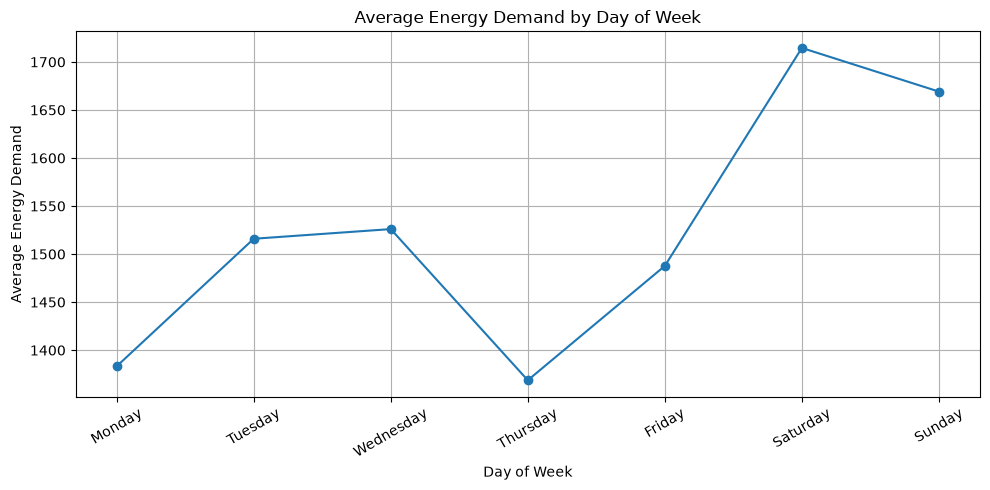

In [68]:
plt.figure(figsize=(10, 5))

plt.plot(weekly_demand.index, weekly_demand.values, marker='o')

plt.xlabel("Day of Week")
plt.ylabel("Average Energy Demand")
plt.title("Average Energy Demand by Day of Week")

plt.xticks(
    range(7),
    ['Monday', 'Tuesday', 'Wednesday', 'Thursday',
     'Friday', 'Saturday', 'Sunday'],
    rotation=30
)

plt.grid(True)
plt.tight_layout()

In [70]:
df.head(20)

,date,AWND,PRCP,TMAX,TMIN,daily_consumption,year,month,day,day_of_week,lag_1,lag_7,rolling_7,rolling_30
87,2007-03-13,1.3,0.0,13.9,6.1,1290.144,2007,3,13,1,1950.668,1246.500,791.682092,962.134004
88,2007-03-14,1.6,0.0,21.1,7.8,1793.364,2007,3,14,2,1290.144,2375.206,783.683185,961.879445
89,2007-03-15,2.8,8.1,19.4,2.2,1884.814,2007,3,15,3,1793.364,1572.132,765.408212,960.057932
90,2007-03-16,5.5,51.6,2.2,-3.3,1702.054,2007,3,16,4,1884.814,1272.612,710.536619,950.043447
91,2007-03-17,3.9,0.8,3.3,-3.9,2028.090,2007,3,17,5,1702.054,2484.712,688.202189,950.457743
92,2007-03-18,4.3,0.0,3.9,-2.8,2371.046,2007,3,18,6,2028.090,3480.636,329.742787,957.352710
93,2007-03-19,2.9,0.0,6.1,-1.1,2152.518,2007,3,19,0,2371.046,1950.668,347.346383,958.307655
94,2007-03-20,3.4,0.0,10.0,0.6,2086.228,2007,3,20,1,2152.518,1290.144,228.711021,878.308353
95,2007-03-21,3.0,0.0,4.4,-3.3,2142.092,2007,3,21,2,2086.228,1793.364,212.981313,877.507290
96,2007-03-22,2.9,0.5,19.4,4.4,1454.978,2007,3,22,3,2142.092,1884.814,309.463308,834.830027


In [35]:
df['lag_1'] = df['daily_consumption'].shift(1)
df['lag_7'] = df['daily_consumption'].shift(7)

7-day average consumption.

In [72]:
df['rolling_7'] = df['daily_consumption'].rolling(7).mean()
df['rolling_30']=df['daily_consumption'].rolling(30).mean()
df.head(20)

,date,AWND,PRCP,TMAX,TMIN,daily_consumption,year,month,day,day_of_week,lag_1,lag_7,rolling_7,rolling_30
87,2007-03-13,1.3,0.0,13.9,6.1,1290.144,2007,3,13,1,1950.668,1246.500,NaN,NaN
88,2007-03-14,1.6,0.0,21.1,7.8,1793.364,2007,3,14,2,1290.144,2375.206,NaN,NaN
89,2007-03-15,2.8,8.1,19.4,2.2,1884.814,2007,3,15,3,1793.364,1572.132,NaN,NaN
90,2007-03-16,5.5,51.6,2.2,-3.3,1702.054,2007,3,16,4,1884.814,1272.612,NaN,NaN
91,2007-03-17,3.9,0.8,3.3,-3.9,2028.090,2007,3,17,5,1702.054,2484.712,NaN,NaN
92,2007-03-18,4.3,0.0,3.9,-2.8,2371.046,2007,3,18,6,2028.090,3480.636,NaN,NaN
93,2007-03-19,2.9,0.0,6.1,-1.1,2152.518,2007,3,19,0,2371.046,1950.668,1888.861429,NaN
94,2007-03-20,3.4,0.0,10.0,0.6,2086.228,2007,3,20,1,2152.518,1290.144,2002.587714,NaN
95,2007-03-21,3.0,0.0,4.4,-3.3,2142.092,2007,3,21,2,2086.228,1793.364,2052.406000,NaN
96,2007-03-22,2.9,0.5,19.4,4.4,1454.978,2007,3,22,3,2142.092,1884.814,1991.000857,NaN


Remove rows created with NaN

In [58]:
df=df.dropna()


In [71]:
df.head(20)

,date,AWND,PRCP,TMAX,TMIN,daily_consumption,year,month,day,day_of_week,lag_1,lag_7,rolling_7,rolling_30
87,2007-03-13,1.3,0.0,13.9,6.1,1290.144,2007,3,13,1,1950.668,1246.500,791.682092,962.134004
88,2007-03-14,1.6,0.0,21.1,7.8,1793.364,2007,3,14,2,1290.144,2375.206,783.683185,961.879445
89,2007-03-15,2.8,8.1,19.4,2.2,1884.814,2007,3,15,3,1793.364,1572.132,765.408212,960.057932
90,2007-03-16,5.5,51.6,2.2,-3.3,1702.054,2007,3,16,4,1884.814,1272.612,710.536619,950.043447
91,2007-03-17,3.9,0.8,3.3,-3.9,2028.090,2007,3,17,5,1702.054,2484.712,688.202189,950.457743
92,2007-03-18,4.3,0.0,3.9,-2.8,2371.046,2007,3,18,6,2028.090,3480.636,329.742787,957.352710
93,2007-03-19,2.9,0.0,6.1,-1.1,2152.518,2007,3,19,0,2371.046,1950.668,347.346383,958.307655
94,2007-03-20,3.4,0.0,10.0,0.6,2086.228,2007,3,20,1,2152.518,1290.144,228.711021,878.308353
95,2007-03-21,3.0,0.0,4.4,-3.3,2142.092,2007,3,21,2,2086.228,1793.364,212.981313,877.507290
96,2007-03-22,2.9,0.5,19.4,4.4,1454.978,2007,3,22,3,2142.092,1884.814,309.463308,834.830027


In [25]:
print(df.columns)

Index(['date', 'AWND', 'PRCP', 'TMAX', 'TMIN', 'daily_consumption', 'year',
       'month', 'day', 'day_of_week', 'lag_1', 'lag_7', 'rolling_7',
       'rolling_30'],
      dtype='str')


Text(0.5, 1.0, 'Daily Energy Demand')

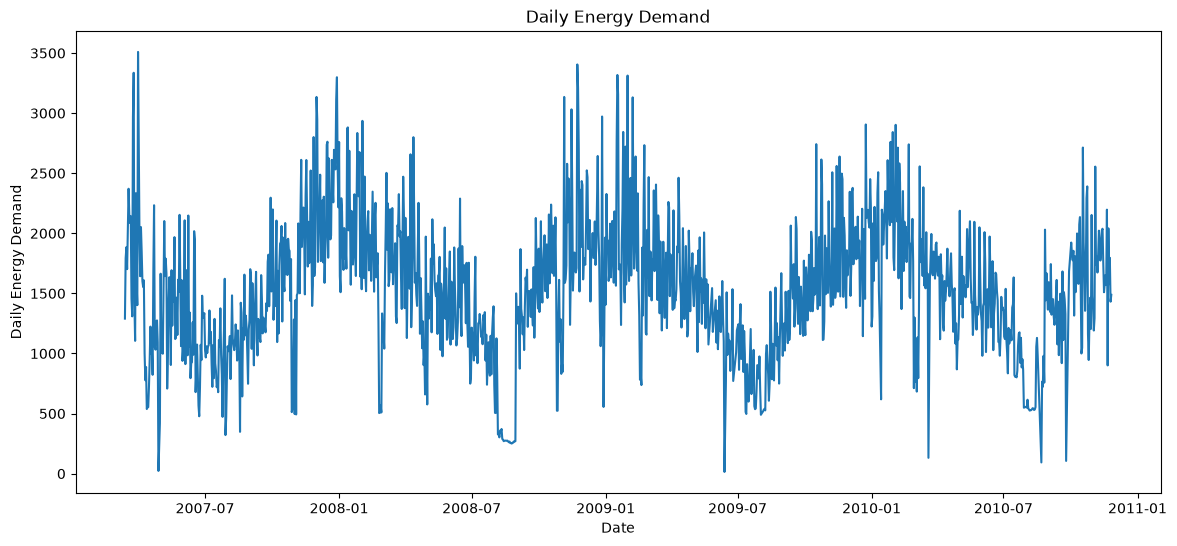

In [63]:
# Plot daily demand
plt.figure(figsize=(14, 6))

plt.plot(
    df['date'],
    df['daily_consumption']
)

plt.xlabel("Date")
plt.ylabel("Daily Energy Demand")
plt.title("Daily Energy Demand")

select x and y ; x= input features, y=output features;

In [40]:
X = df[
    ['AWND', 'PRCP', 'TMAX', 'TMIN',
     'year', 'month', 'day', 'day_of_week',
     'lag_1', 'lag_7', 'rolling_7','rolling_30']
]

In [41]:
y = df['daily_consumption']

In [42]:
df.head()

,date,AWND,PRCP,TMAX,TMIN,daily_consumption,year,month,day,day_of_week,lag_1,lag_7,rolling_7,rolling_30
58,2007-02-12,2.6,0.0,4.4,-2.2,1877.610,2007,2,12,0,3571.228,1645.280,2185.896571,2298.233000
59,2007-02-13,3.6,0.8,0.0,-5.6,1414.546,2007,2,13,1,1877.610,1273.480,2206.048857,2245.124000
60,2007-02-14,6.2,23.9,-1.7,-8.9,2498.672,2007,2,14,2,1414.546,2328.018,2230.428000,2256.790467
61,2007-02-15,4.7,0.0,-4.4,-9.4,1985.346,2007,2,15,3,2498.672,1801.414,2256.704000,2266.755200
62,2007-02-16,4.4,0.0,-1.7,-10.0,1702.528,2007,2,16,4,1985.346,1620.198,2268.465429,2228.583200


In [43]:
split = int(len(df) * 0.8)

In [44]:
X_train = X.iloc[:split]
X_test = X.iloc[split:]

In [45]:
y_train = y.iloc[:split]
y_test = y.iloc[split:]

In [74]:
X_train

,AWND,PRCP,TMAX,TMIN,year,month,day,day_of_week,lag_1,lag_7,rolling_7,rolling_30
58,2.6,0.0,4.4,-2.2,2007,2,12,0,3571.228,1645.280,2185.896571,2298.233000
59,3.6,0.8,0.0,-5.6,2007,2,13,1,1877.610,1273.480,2206.048857,2245.124000
60,6.2,23.9,-1.7,-8.9,2007,2,14,2,1414.546,2328.018,2230.428000,2256.790467
61,4.7,0.0,-4.4,-9.4,2007,2,15,3,2498.672,1801.414,2256.704000,2266.755200
62,4.4,0.0,-1.7,-10.0,2007,2,16,4,1985.346,1620.198,2268.465429,2228.583200
...,...,...,...,...,...,...,...,...,...,...,...,...
1153,4.1,0.0,3.9,-2.2,2010,2,14,6,2351.556,1625.708,2035.533143,2091.434000
1154,3.1,0.3,4.4,-2.8,2010,2,15,0,1686.698,2582.238,1966.232286,2118.587133
1155,2.5,10.9,0.6,-1.7,2010,2,16,1,2097.132,2420.932,1877.207143,2157.896067
1156,3.6,0.0,1.7,-3.3,2010,2,17,2,1797.756,1944.542,1892.924000,2153.156067


In [75]:
y_train

58      1877.610
59      1414.546
60      2498.672
61      1985.346
62      1702.528
          ...   
1153    1686.698
1154    2097.132
1155    1797.756
1156    2054.560
1157    1761.156
Name: daily_consumption, Length: 1088, dtype: float64

In [47]:
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (1088, 12)
X_test: (272, 12)
y_train: (1088,)
y_test: (272,)


In [73]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor

In [85]:
lr=LinearRegression()
rf=RandomForestRegressor()
gbr=GradientBoostingRegressor()

Train Regression

In [86]:
lr.fit(X_train, y_train)
rf.fit(X_train, y_train)
gbr.fit(X_train, y_train)

,"loss loss: {'squared_error', 'absolute_error', 'huber', 'quantile'}, default='squared_error'Loss function to be optimized. 'squared_error' refers to the squarederror for regression. 'absolute_error' refers to the absolute error ofregression and is a robust loss function. 'huber' is acombination of the two. 'quantile' allows quantile regression (use`alpha` to specify the quantile).See:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_quantile.py`for an example that demonstrates quantile regression for creatingprediction intervals with `loss='quantile'`.",'squared_error'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.",0.1
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",100
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'This parameter has no effect... versionadded:: 0.18.. deprecated:: 1.9 `criterion` is deprecated and will be removed in 1.11.",'deprecated'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"init in

In [101]:
y_pred1 = lr.predict(X_test)
y_pred2 = rf.predict(X_test)
y_pred3 = gbr.predict(X_test)

Evaluation

In [89]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

In [90]:
score1 = r2_score(y_test, y_pred1)
score2 = r2_score(y_test,y_pred2)
score3 = r2_score(y_test,y_pred3)

In [91]:

print("R² Score :", score1)
print("R² Score :", score2)
print("R² Score :", score3)

R² Score : 0.4750063328826063
R² Score : 0.4896579487055944
R² Score : 0.442775359777555


Compare Actual and Predicted values

for linear regression

In [102]:
pred1 = lr.predict(X_test)
pred2 = rf.predict(X_test)
pred3 = gbr.predict(X_test)

In [103]:
import pandas as pd

comparison = pd.DataFrame({
    'Actual Demand': y_test.values,
    'Predicted Demand': y_pred1
})

comparison.head(10)

,Actual Demand,Predicted Demand
0,1953.572,1943.717396
1,1983.728,1946.695341
2,2740.314,2128.654394
3,1474.036,1793.886137
4,1461.280,1731.274037
5,1914.278,1743.351169
6,1880.204,1792.913623
7,2120.156,1902.298348
8,1765.056,1939.640525
9,711.666,1706.190498


for Random Forest

In [104]:
comparison = pd.DataFrame({
    'Actual Demand': y_test.values,
    'Predicted Demand': pred2
})

comparison.head(10)

,Actual Demand,Predicted Demand
0,1953.572,1918.36200
1,1983.728,2060.33874
2,2740.314,2085.04926
3,1474.036,1855.70570
4,1461.280,1942.66594
5,1914.278,2015.15206
6,1880.204,1725.32596
7,2120.156,1762.90154
8,1765.056,2054.85646
9,711.666,1447.45176


for Gradient Boosting

In [105]:
comparison = pd.DataFrame({
    'Actual Demand': y_test.values,
    'Predicted Demand': pred3
})

comparison.head(10)

,Actual Demand,Predicted Demand
0,1953.572,1788.405044
1,1983.728,2145.601593
2,2740.314,2195.972367
3,1474.036,1793.522608
4,1461.280,2119.939400
5,1914.278,1875.547897
6,1880.204,1687.631575
7,2120.156,1790.977053
8,1765.056,2133.432752
9,711.666,1796.371026


Predict demand of the elctricity

In [106]:
df.head(1)

,date,AWND,PRCP,TMAX,TMIN,daily_consumption,year,month,day,day_of_week,lag_1,lag_7,rolling_7,rolling_30
87,2007-03-13,1.3,0.0,13.9,6.1,1290.144,2007,3,13,1,1950.668,1246.5,NaN,NaN


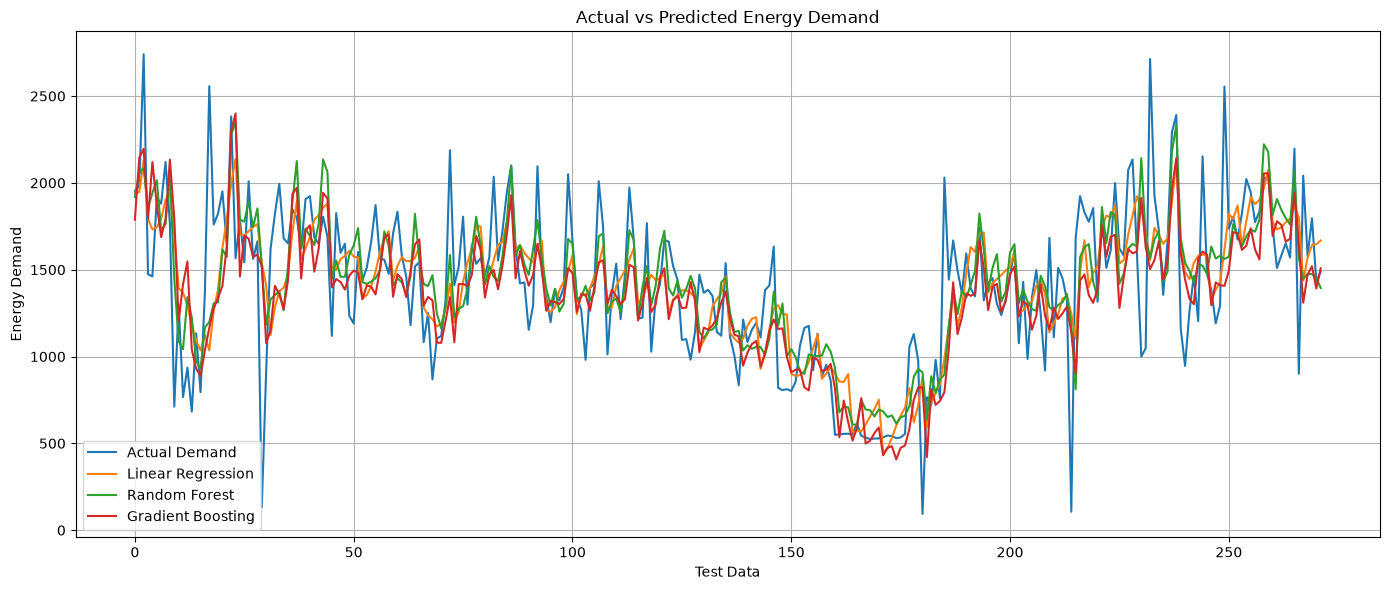

In [107]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 6))

plt.plot(y_test.values, label="Actual Demand")
plt.plot(pred1, label="Linear Regression")
plt.plot(pred2, label="Random Forest")
plt.plot(pred3, label="Gradient Boosting")

plt.xlabel("Test Data")
plt.ylabel("Energy Demand")
plt.title("Actual vs Predicted Energy Demand")

plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [108]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

In [109]:
# Linear Regression
mae1 = mean_absolute_error(y_test, pred1)
rmse1 = np.sqrt(mean_squared_error(y_test, pred1))
r2_1 = r2_score(y_test, pred1)

In [110]:
# Random Forest
mae2 = mean_absolute_error(y_test, pred2)
rmse2 = np.sqrt(mean_squared_error(y_test, pred2))
r2_2 = r2_score(y_test, pred2)

In [111]:

# Gradient Boosting
mae3 = mean_absolute_error(y_test, pred3)
rmse3 = np.sqrt(mean_squared_error(y_test, pred3))
r2_3 = r2_score(y_test, pred3)

In [112]:
print("Linear Regression")
print("MAE :", mae1)
print("RMSE:", rmse1)
print("R²  :", r2_1)

Linear Regression
MAE : 238.97189761275845
RMSE: 331.62671527050776
R²  : 0.4750063328826063


In [113]:
print("\nRandom Forest")
print("MAE :", mae2)
print("RMSE:", rmse2)
print("R²  :", r2_2)


Random Forest
MAE : 235.74304735294118
RMSE: 326.9664216965352
R²  : 0.4896579487055944


In [114]:
print("\nGradient Boosting")
print("MAE :", mae3)
print("RMSE:", rmse3)
print("R²  :", r2_3)


Gradient Boosting
MAE : 245.75639342613346
RMSE: 341.6548838571063
R²  : 0.442775359777555


In [115]:

results = pd.DataFrame({
    'Model': [
        'Linear Regression',
        'Random Forest',
        'Gradient Boosting'
    ],
    'MAE': [mae1, mae2, mae3],
    'RMSE': [rmse1, rmse2, rmse3],
    'R2 Score': [r2_1, r2_2, r2_3]
})

results

,Model,MAE,RMSE,R2 Score
0,Linear Regression,238.971898,331.626715,0.475006
1,Random Forest,235.743047,326.966422,0.489658
2,Gradient Boosting,245.756393,341.654884,0.442775


model comparison graph

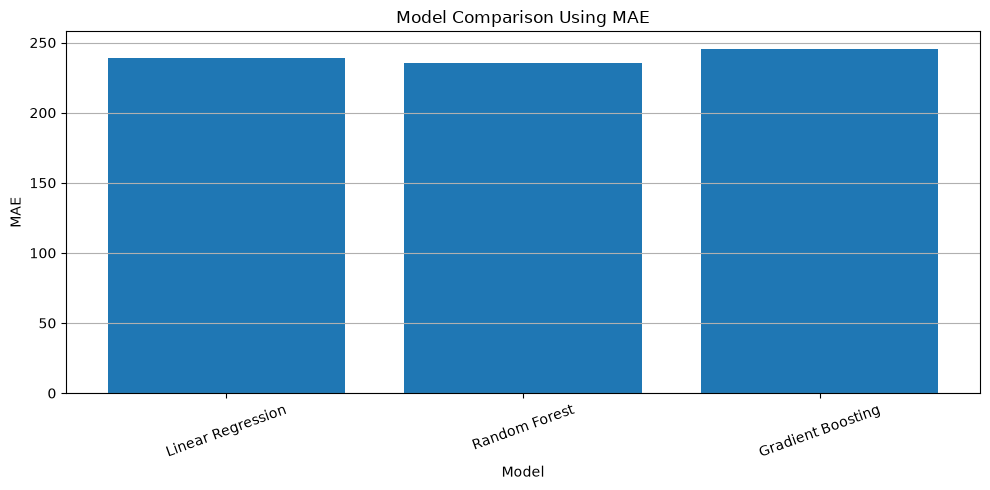

In [116]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plt.bar(results['Model'], results['MAE'])

plt.xlabel("Model")
plt.ylabel("MAE")
plt.title("Model Comparison Using MAE")

plt.xticks(rotation=20)
plt.grid(axis='y')
plt.tight_layout()
plt.show()

In [ ]:
Actual vs Predicted graph for random forest

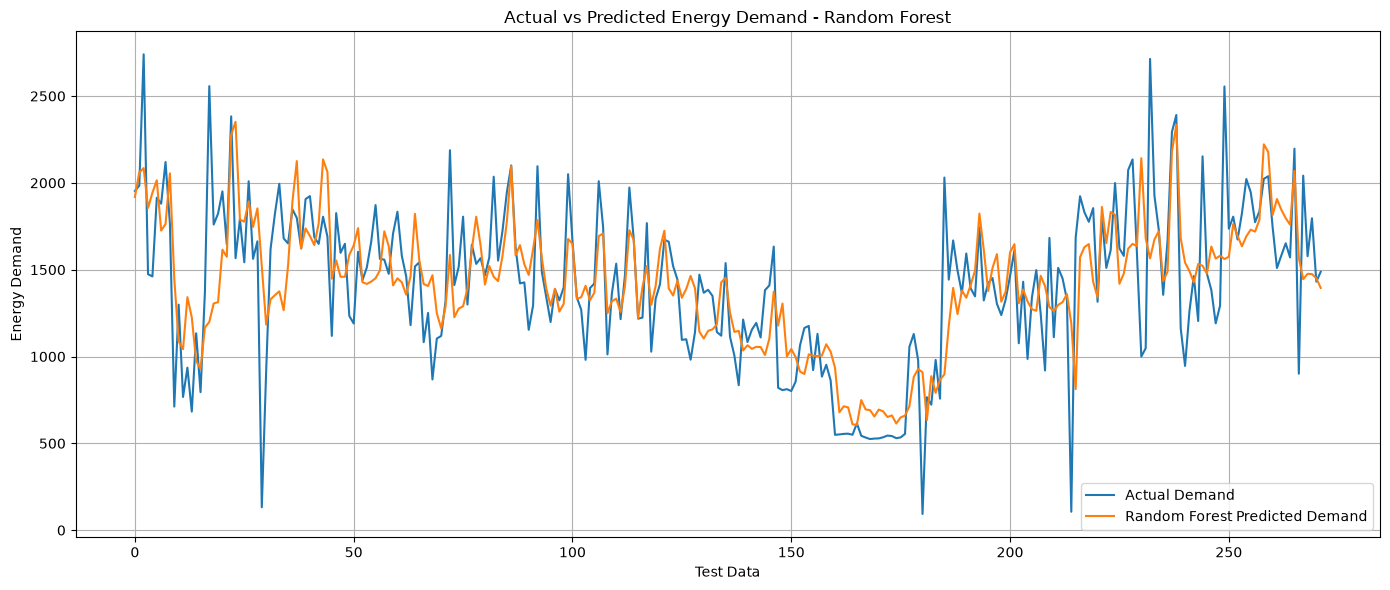

In [122]:
plt.figure(figsize=(14, 6))

plt.plot(y_test.values, label="Actual Demand")
plt.plot(pred2, label="Random Forest Predicted Demand")

plt.xlabel("Test Data")
plt.ylabel("Energy Demand")
plt.title("Actual vs Predicted Energy Demand - Random Forest")

plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [ ]:
Feature Importance

In [123]:
importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': rf.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

print(importance)

        Feature  Importance
10    rolling_7    0.596842
8         lag_1    0.079639
7   day_of_week    0.066649
9         lag_7    0.053457
11   rolling_30    0.046979
0          AWND    0.032068
6           day    0.030998
3          TMIN    0.026738
2          TMAX    0.026235
5         month    0.018445
1          PRCP    0.012759
4          year    0.009190


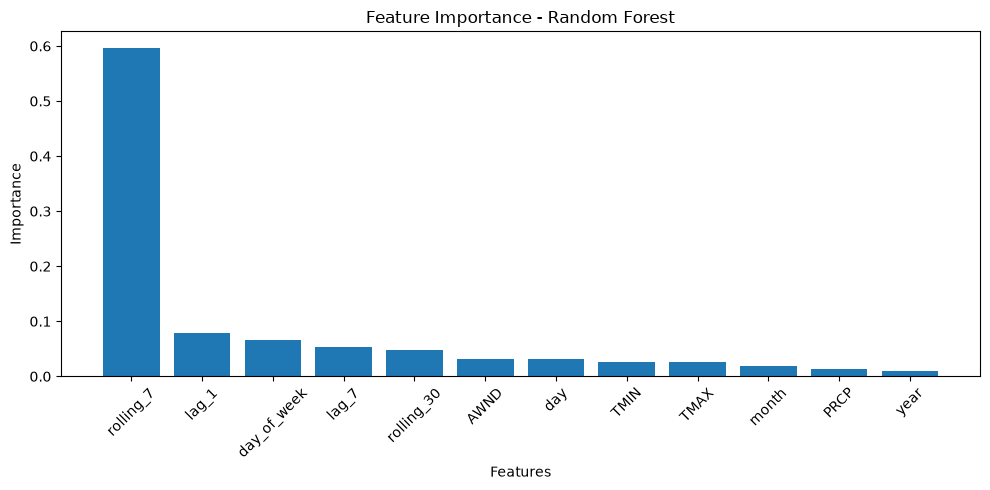

In [124]:
plt.figure(figsize=(10, 5))

plt.bar(
    importance['Feature'],
    importance['Importance']
)

plt.xlabel("Features")
plt.ylabel("Importance")
plt.title("Feature Importance - Random Forest")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Analyze the error

In [120]:
comparison = pd.DataFrame({
    'Actual Demand': y_test.values,
    'Predicted Demand': pred2
})

comparison['Error'] = (
    comparison['Actual Demand'] -
    comparison['Predicted Demand']
)

comparison.head(10)

,Actual Demand,Predicted Demand,Error
0,1953.572,1918.36200,35.21000
1,1983.728,2060.33874,-76.61074
2,2740.314,2085.04926,655.26474
3,1474.036,1855.70570,-381.66970
4,1461.280,1942.66594,-481.38594
5,1914.278,2015.15206,-100.87406
6,1880.204,1725.32596,154.87804
7,2120.156,1762.90154,357.25446
8,1765.056,2054.85646,-289.80046
9,711.666,1447.45176,-735.78576


In [121]:
comparison['Absolute Error'] = abs(comparison['Error'])
comparison.head(10)

,Actual Demand,Predicted Demand,Error,Absolute Error
0,1953.572,1918.36200,35.21000,35.21000
1,1983.728,2060.33874,-76.61074,76.61074
2,2740.314,2085.04926,655.26474,655.26474
3,1474.036,1855.70570,-381.66970,381.66970
4,1461.280,1942.66594,-481.38594,481.38594
5,1914.278,2015.15206,-100.87406,100.87406
6,1880.204,1725.32596,154.87804,154.87804
7,2120.156,1762.90154,357.25446,357.25446
8,1765.056,2054.85646,-289.80046,289.80046
9,711.666,1447.45176,-735.78576,735.78576


In [132]:
import joblib
model = joblib.load("energy_demand_model.pkl")
print(model)

RandomForestRegressor()


In [133]:
print(X_train.columns.tolist())

['AWND', 'PRCP', 'TMAX', 'TMIN', 'year', 'month', 'day', 'day_of_week', 'lag_1', 'lag_7', 'rolling_7', 'rolling_30']
